In [85]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from cycler import cycler
import sqlite3


from md_output_parser import MDVideoOutputParser

In [81]:
# util function
def plot_frequencies(annotated_tracklets_df, col_name):
    fig, ax = plt.subplots(1,1, figsize=(12,8))
    
    if isinstance(col_name, list):
            df = pd.concat([
                annotated_tracklets_df
                .groupby(col)
                .agg({"event_id": pd.Series.nunique})
                for col in col_name], axis=0)
            attributes_df = df.groupby(level=0).sum().sort_values("event_id", ascending=False)
    else:
        attributes_df = (
            annotated_tracklets_df
            .groupby(col_name)
            .agg({"event_id": pd.Series.nunique})
            .sort_values("event_id", ascending=False)
        )

    attributes_df["perc"] = attributes_df["event_id"] * 100 / attributes_df["event_id"].sum()

    
    attributes_df[["event_id"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax)
    
    ax.set_xticklabels(attributes_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
    
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(attributes_df.iterrows()):
        bar = ax.patches[i]
        height = bar.get_height() + 2
        perc = "<1" if row["perc"] < 1.0 else f'{row["perc"]:.1f}'
        color = "red" if row["event_id"] <= 5 else "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{row["event_id"]:.0f}\n({perc})%', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            color=color
        )
    ax.set_ylim(0, attributes_df["event_id"].max() + 20)
    ax.get_legend().set_visible(False)
    plt.show()

    return attributes_df

# Figure aesthetics
mpl_config = {
    "figure.figsize": (12, 8),
    "figure.dpi": 100,
    "figure.facecolor": "white",

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 15,

    # Title and Label size
    "axes.titlesize": 20,
    "axes.labelsize": 15,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Grid and Spines for readability
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": True,
    "legend.loc": "best",
}

plt.rcParams.update(mpl_config)

# 2023 Previous

In [3]:
cmap = plt.get_cmap('Greens_r')
colors = [cmap(i) for i in np.linspace(0.5, 0.7, 3)]  # Sample 7 colors

# Apply the configuration
plt.rcParams.update({"axes.prop_cycle": cycler(color=colors)})

# Load annotations in JSON format
annotated_tracklets_folder = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_species_tracks")
database_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/raw_videos_metadata.csv")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df.sample(2)

  0%|          | 0/1746 [00:00<?, ?it/s]

100%|██████████| 1746/1746 [00:07<00:00, 225.23it/s]


,frame_id,max_detection_conf,detections,width,height,file_id,detection_file_path,conf,category,track_id,...,attributes.Action2,attributes.Activity,attributes.red_deer_age_group,attributes.red_deer_adult_sex,attributes.species,outside,attributes.Interacting,attributes.Species,attributes.Sex,attributes.Age group
414721,3208,1.0,"{'conf': 1.0, 'track_id': 2, 'bbox': [0.566666...",1920,1080,S1_C3_E36_V0018,S1/C3/S1_C3_E36_V0018_tracks.frames.json,1.0,1.0,2.0,...,none,foraging,young,unknown,red_deer,False,NaN,NaN,NaN,NaN
25482,452,1.0,"{'conf': 1.0, 'track_id': 1, 'bbox': [0.347135...",1920,1080,S1_C1_E36_V0073,S1/C1/S1_C1_E36_V0073_tracks.frames.json,1.0,1.0,1.0,...,none,foraging,adult,female,red_deer,False,NaN,NaN,NaN,NaN


In [4]:
videos_metadata_df = pd.read_csv(database_path)

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "frame_id", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.red_deer_age_group", "attributes.red_deer_adult_sex", "attributes.species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_id", "cam_id"]], on="file_id")
)

none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]
annotated_tracklets_df = annotated_tracklets_df.rename(columns={"attributes.red_deer_age_group": "attributes.deer_age","attributes.red_deer_adult_sex":"attributes.deer_adult_sex"})
annotated_tracklets_df["attributes.deer_age"] = annotated_tracklets_df["attributes.deer_age"].str.replace("young", "juvenile")
annotated_tracklets_df["attributes.action"] = annotated_tracklets_df["attributes.action"].str.replace("none", "unknown")
annotated_tracklets_df["attributes.activity"] = annotated_tracklets_df["attributes.activity"].str.replace("none", "unknown")

annotated_tracklets_df.sample(2)

,file_id,frame_id,attributes.action,attributes.action2,attributes.activity,attributes.deer_age,attributes.deer_adult_sex,attributes.species,event_id,date_time,site_id,cam_id
886972,S3_C2_E780_V0470,1567,standing_head_up,NaN,vigilance,adult,male,red_deer,E780,2023-09-29 17:57:52,S3,C2
444837,S2_C1_E301_V0049,508,standing_head_up,NaN,vigilance,adult,female,red_deer,E301,2023-09-05 06:57:48,S2,C1


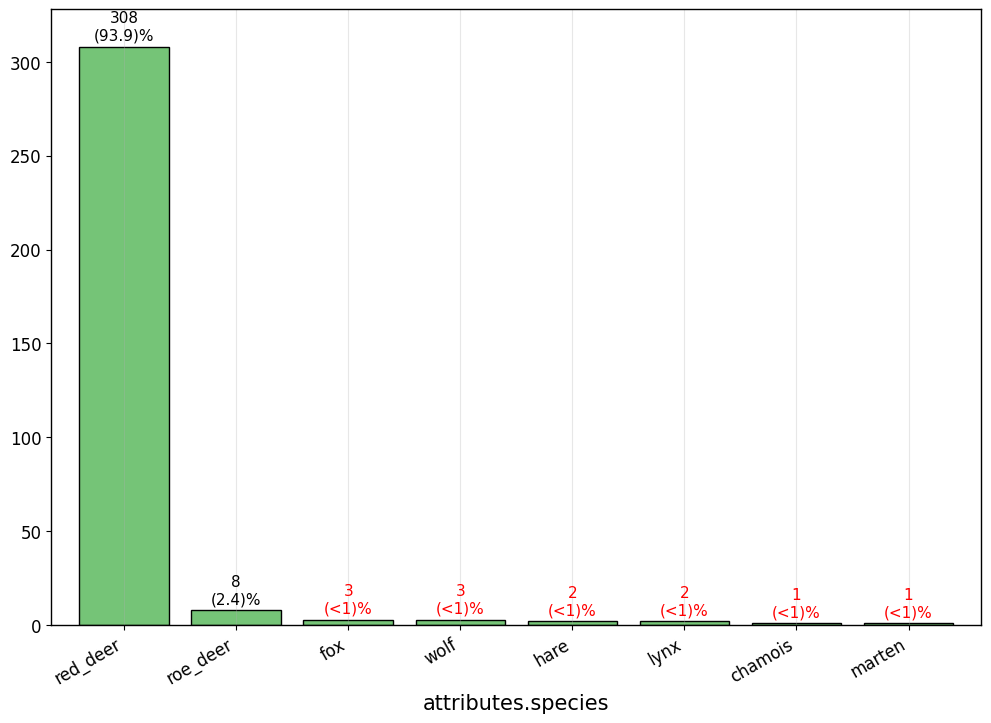

In [5]:
hare_idx = annotated_tracklets_df[(annotated_tracklets_df["attributes.species"] == "unknown") | (annotated_tracklets_df["file_id"] == "S1_C1_E51_V0116")].index # hare
marten_idx = annotated_tracklets_df[annotated_tracklets_df["file_id"] == "S2_C2_E318_V0068"].index

annotated_tracklets_df.loc[hare_idx, "attributes.species"] = "hare"
annotated_tracklets_df.loc[marten_idx, "attributes.species"] = "marten"

annotated_tracklets_df_2023 = annotated_tracklets_df.copy()
species_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.species")

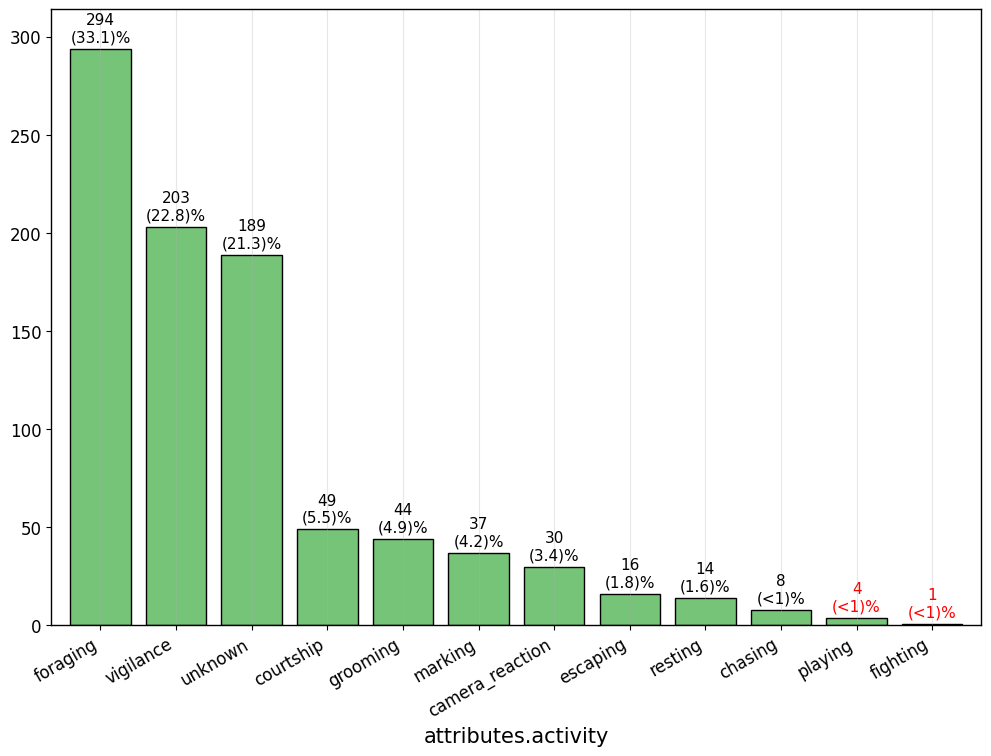

In [6]:
acty_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.activity")

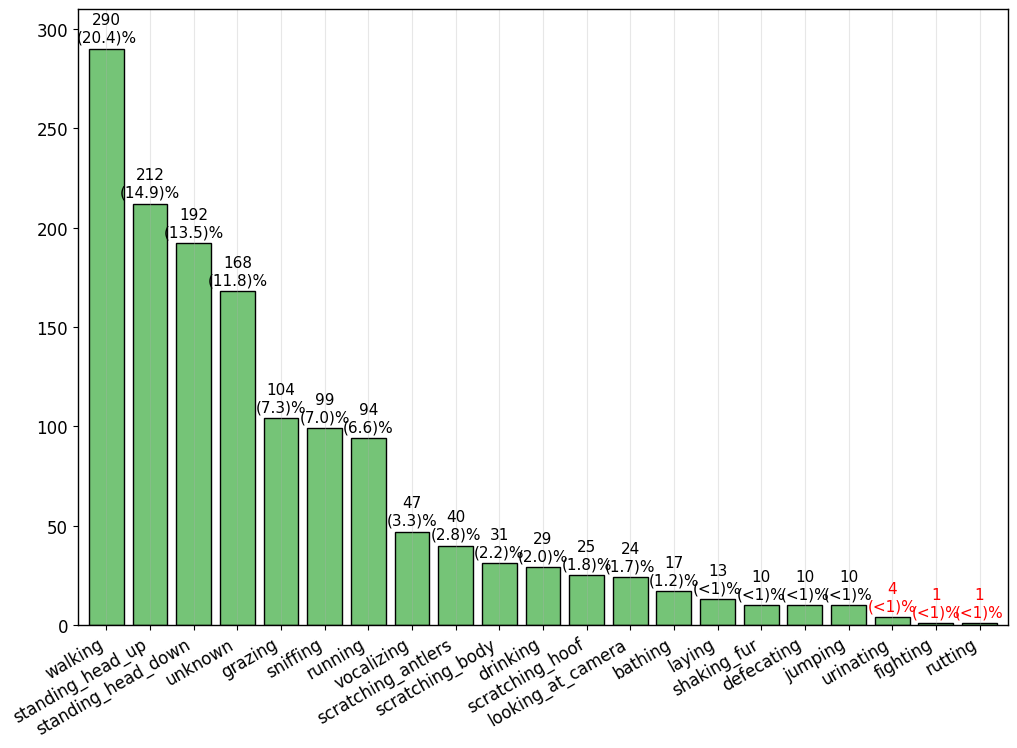

In [7]:
actn_df_2023 = plot_frequencies(annotated_tracklets_df, ["attributes.action", "attributes.action2"])

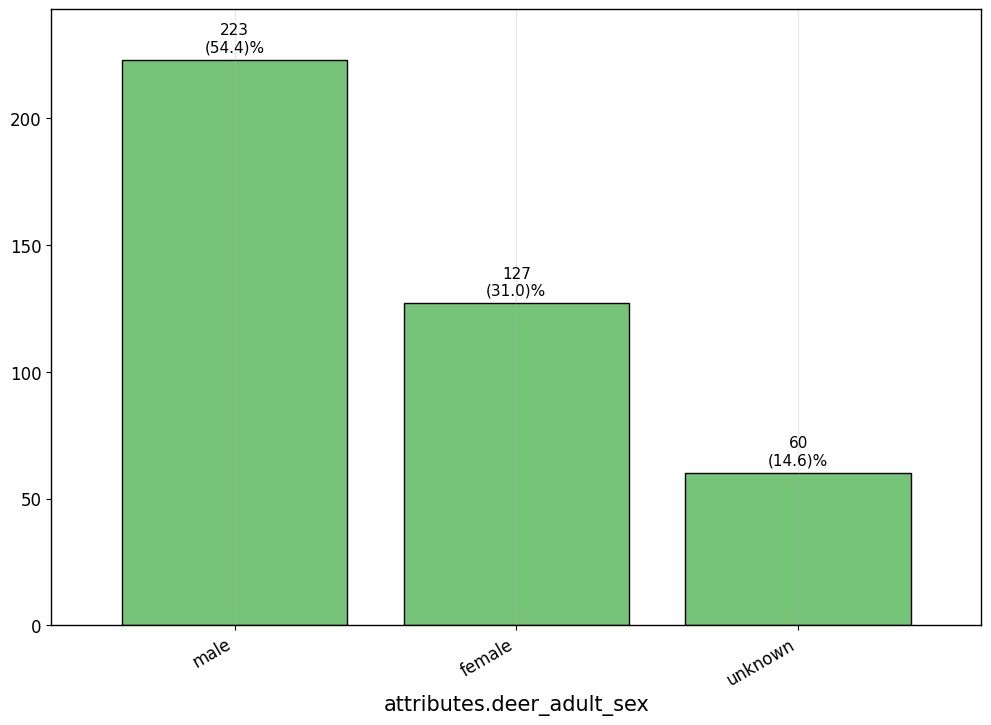

In [8]:
sex_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_adult_sex")

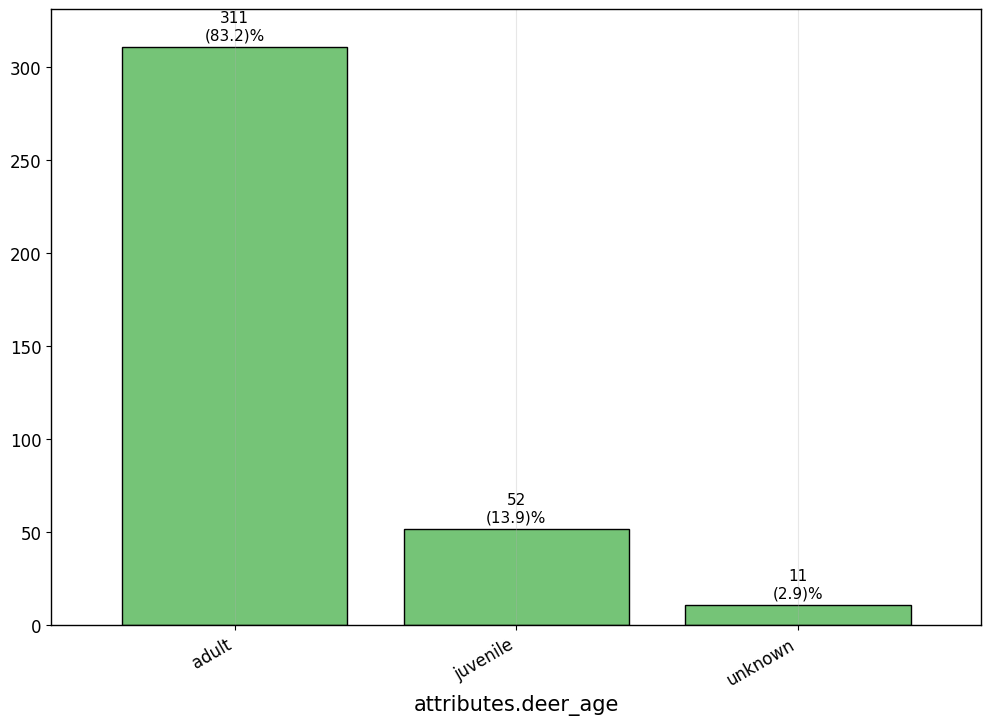

In [9]:
age_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_age")

# 2023 Updated

In [49]:
cmap = plt.get_cmap('Reds_r')
colors = [cmap(i) for i in np.linspace(0.5, 0.7, 3)]  # Sample 7 colors

# Apply the configuration
plt.rcParams.update({"axes.prop_cycle": cycler(color=colors)})

# Load annotations in JSON format
annotated_tracklets_folder = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_tracks_v5")
database_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/raw_videos_metadata.csv")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df.sample(2)

100%|██████████| 1746/1746 [00:13<00:00, 130.63it/s]


,frame_id,max_detection_conf,detections,width,height,file_id,detection_file_path,conf,category,track_id,...,attributes.Action2,attributes.Social_activity_role,attributes.Action,attributes.Species,attributes.Deer_adult_sex,attributes.Deer_age,outside,attributes.Interacting,attributes.Sex,attributes.Age group
587170,2225,0.000,NaN,1920,1080,S1_C1_E139_V0706,S1/C1/S1_C1_E139_V0706.json,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
617583,8,0.959,"{'conf': 0.9589999914169312, 'category': 1, 't...",1920,1080,S1_C3_E67_V0031,S1/C3/S1_C3_E67_V0031.json,0.959,1.0,1.0,...,none,n/a,sniffing,red_deer,male,adult,NaN,NaN,NaN,NaN


In [50]:
videos_metadata_df = pd.read_csv(database_path)

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "frame_id", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_age", "attributes.Deer_adult_sex", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_id", "cam_id"]], on="file_id")
)

none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]
annotated_tracklets_df = annotated_tracklets_df.rename(columns={"attributes.red_deer_age_group": "attributes.deer_age","attributes.red_deer_adult_sex":"attributes.deer_adult_sex"})
annotated_tracklets_df["attributes.deer_age"] = annotated_tracklets_df["attributes.deer_age"].str.replace("young", "juvenile")
annotated_tracklets_df["attributes.action"] = annotated_tracklets_df["attributes.action"].str.replace("none", "unknown")
annotated_tracklets_df["attributes.activity"] = annotated_tracklets_df["attributes.activity"].str.replace("none", "unknown")

red_deer_fmt_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.species"] == "red deer"].index
annotated_tracklets_df.loc[red_deer_fmt_idx, "attributes.species"] = "red_deer"
marten_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.species"] == "other_small_mammal"].index
annotated_tracklets_df.loc[marten_idx, "attributes.species"] = "marten"
annotated_tracklets_df.sample(2)

,file_id,frame_id,attributes.action,attributes.action2,attributes.activity,attributes.deer_age,attributes.deer_adult_sex,attributes.species,event_id,date_time,site_id,cam_id
680856,S3_C2_E693_V0182,654,bathing,NaN,grooming,juvenile,NaN,red_deer,E693,2023-09-14 19:38:52,S3,C2
703565,S3_C2_E769_V0434,956,standing_head_up,NaN,vigilance,adult,male,red_deer,E769,2023-09-28 15:29:42,S3,C2


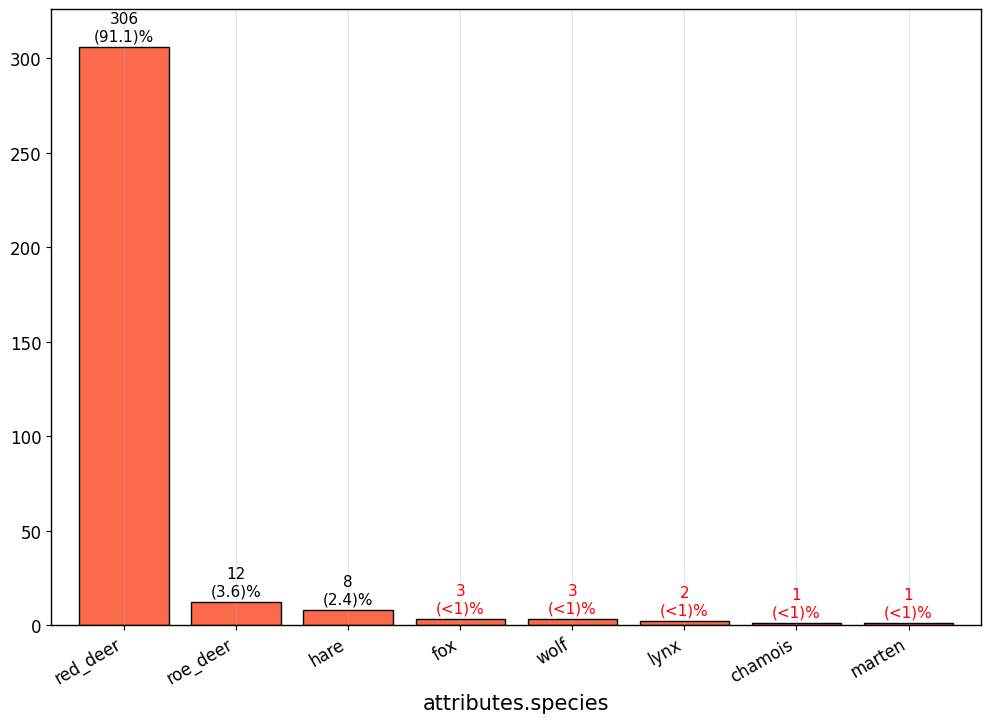

In [51]:
hare_idx = annotated_tracklets_df[(annotated_tracklets_df["attributes.species"] == "unknown") | (annotated_tracklets_df["file_id"] == "S1_C1_E51_V0116")].index # hare
marten_idx = annotated_tracklets_df[annotated_tracklets_df["file_id"] == "S2_C2_E318_V0068"].index

annotated_tracklets_df.loc[hare_idx, "attributes.species"] = "hare"
annotated_tracklets_df.loc[marten_idx, "attributes.species"] = "marten"

annotated_tracklets_df_2023_updated = annotated_tracklets_df.copy()
species_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.species")

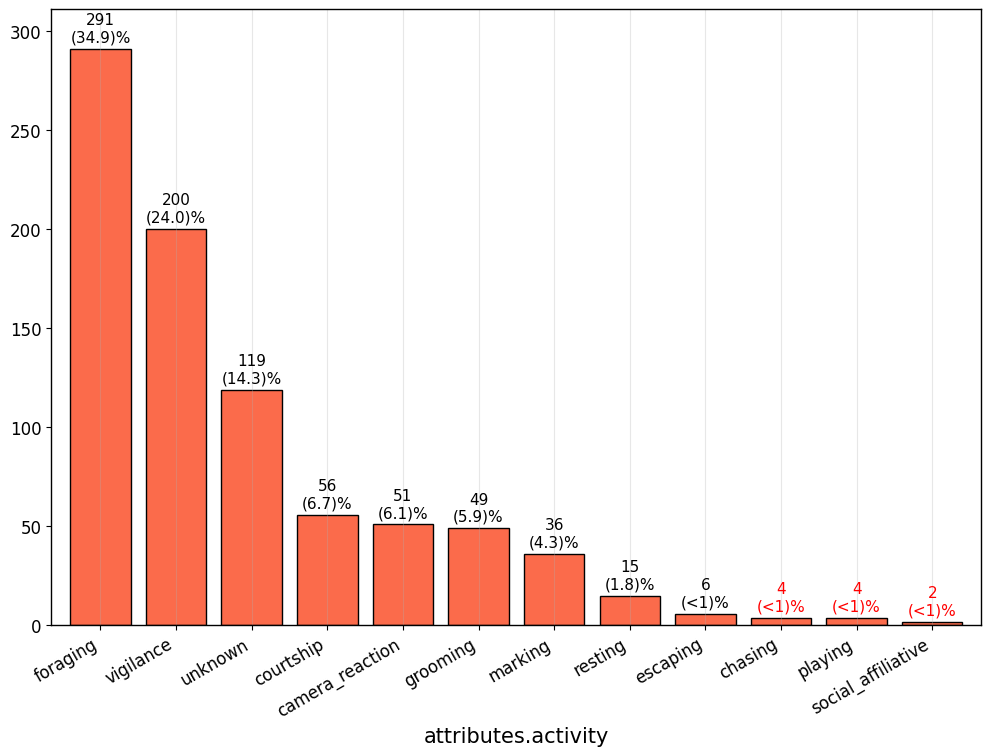

In [52]:
acty_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.activity")

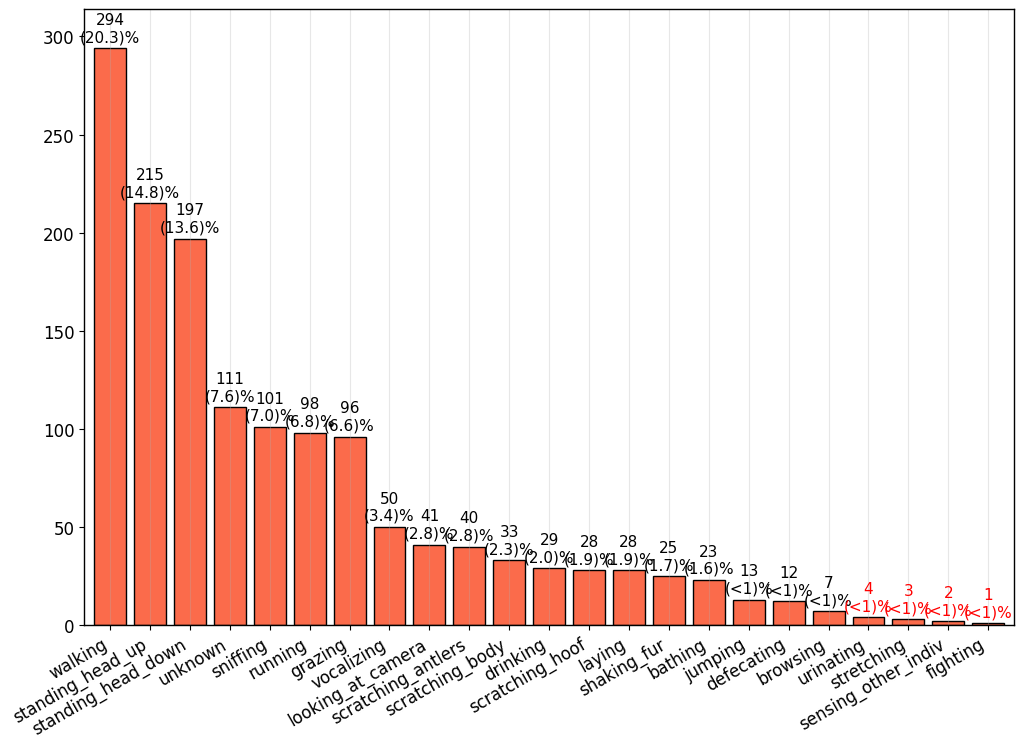

In [53]:
actn_df_2023 = plot_frequencies(annotated_tracklets_df, ["attributes.action", "attributes.action2"])

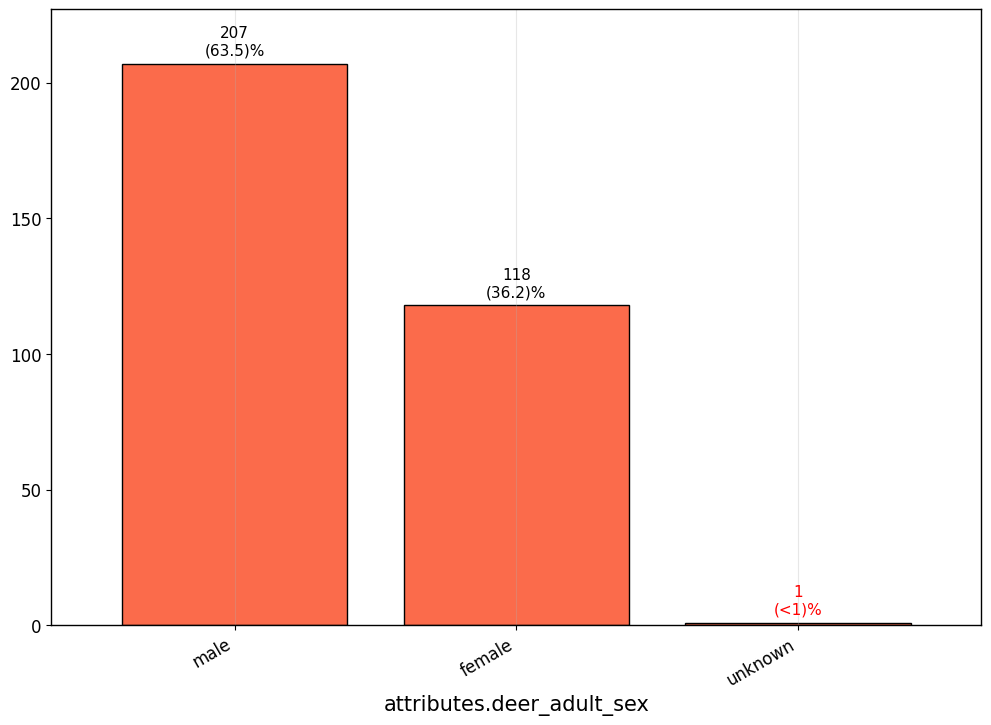

In [54]:
sex_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_adult_sex")

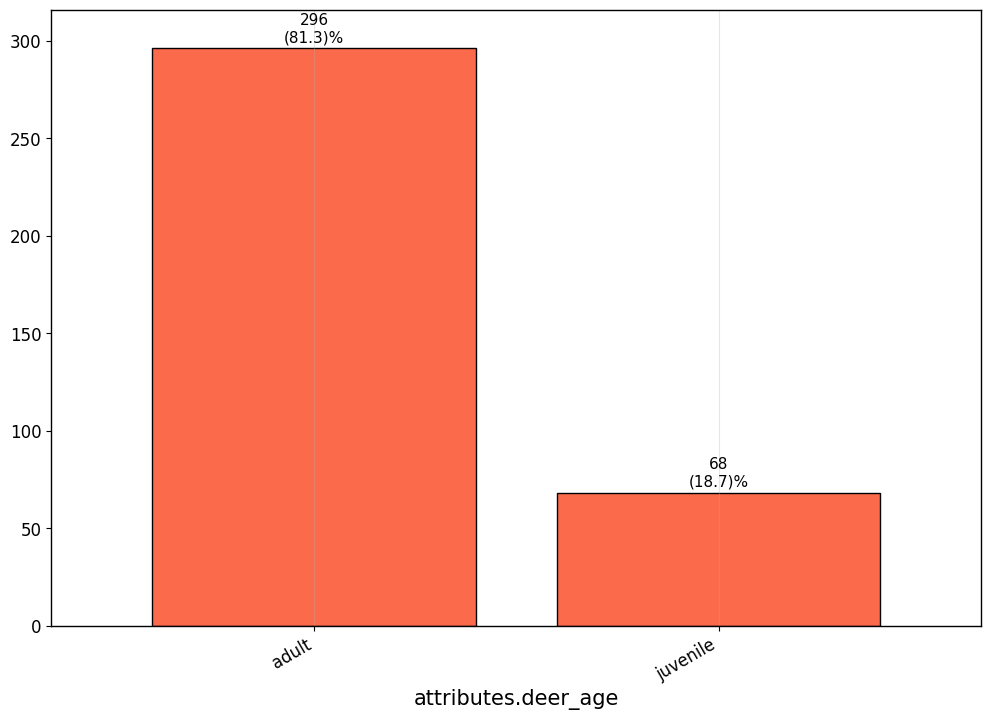

In [55]:
age_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_age")

In [56]:
attr_cols = ["attributes.action", "attributes.action2", "attributes.activity", "attributes.deer_age", "attributes.deer_adult_sex", "attributes.species"]
diff_df = annotated_tracklets_df_2023_updated.sort_values(["file_id", "frame_id"]).fillna(-1).reset_index(drop=True).copy()
diff_df[attr_cols] = annotated_tracklets_df_2023_updated.sort_values(["file_id", "frame_id"]).fillna(-1).reset_index(drop=True)[attr_cols] != annotated_tracklets_df_2023.sort_values(["file_id", "frame_id"]).fillna(-1).reset_index(drop=True)[attr_cols]

In [57]:
# At least one attribute changed (% of frames)
print(diff_df[attr_cols].any(axis=1).sum() / len(diff_df) * 100)

31.432327140104466


In [58]:
# Change per attribute (% of frames)
diff_df[attr_cols].sum(axis=0) / len(diff_df) * 100

attributes.action             5.762947
attributes.action2            2.508580
attributes.activity          10.519265
attributes.deer_age           6.468719
attributes.deer_adult_sex    19.924290
attributes.species            1.324316
dtype: float64

In [59]:
diff_per_file_df = diff_df.groupby("file_id")[attr_cols].agg(pd.Series.any)
print(diff_per_file_df.any(axis=1).sum() / len(diff_per_file_df))

0.4753722794959908


In [60]:
diff_per_file_df.sum(axis=0) / len(diff_per_file_df) * 100

attributes.action            25.887743
attributes.action2            7.159221
attributes.activity          33.218786
attributes.deer_age          15.349370
attributes.deer_adult_sex    22.336770
attributes.species            1.030928
dtype: float64

In [61]:
def plot_changed_frames_frequency(attr, annotated_df, diff_df, xlabel_title):
    index_change_attr = diff_df[diff_df[attr]].index
    attr_count_df = (
        annotated_df[[attr]]
        .reset_index(drop=False, names="total_frames")
        .dropna()
        .groupby(attr)
        .count()
    )
    attr_changed_df = (
        annotated_df
        .sort_values(["file_id", "frame_id"])
        .reset_index(drop=True)
        .loc[index_change_attr, [attr]]
        .reset_index(drop=False, names="updated_frames")
        .dropna()
        .groupby(attr)
        .count()
    )
    (
        attr_changed_df
        .merge(attr_count_df, left_index=True, right_index=True)
        .assign(prop_frames= lambda d: d.updated_frames / d.total_frames)
        .sort_values("prop_frames", ascending=False)
        [["prop_frames"]]
        .plot(kind="bar")
    )
    plt.xlabel(xlabel_title)
    plt.xticks(rotation=30, ha="right")
    plt.show()

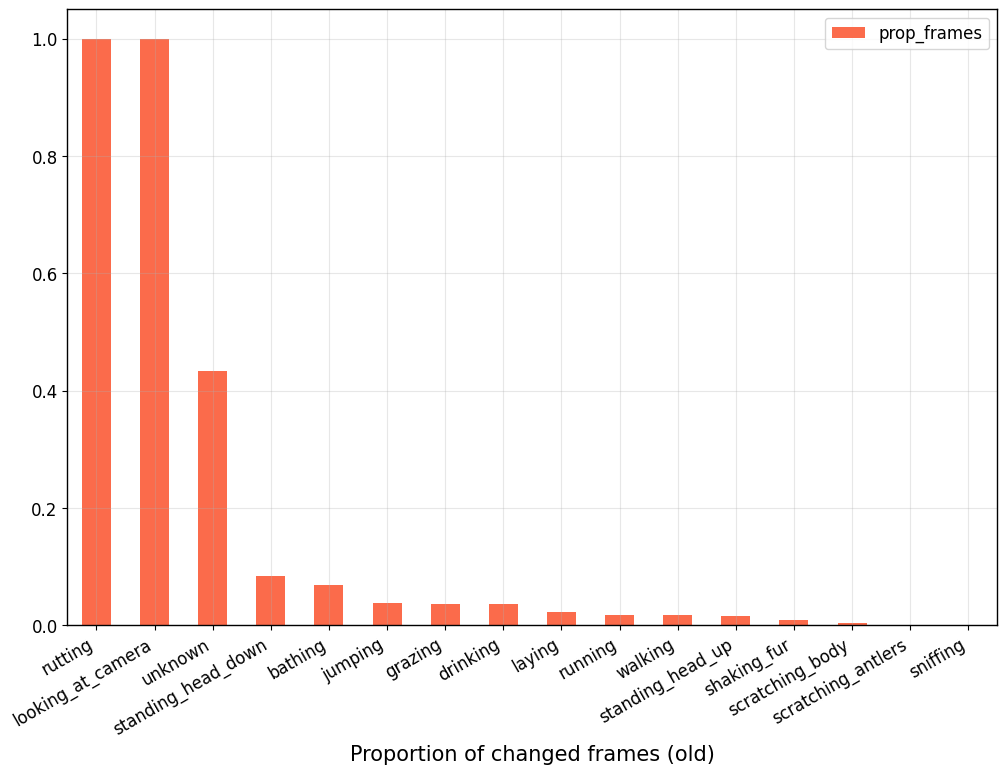

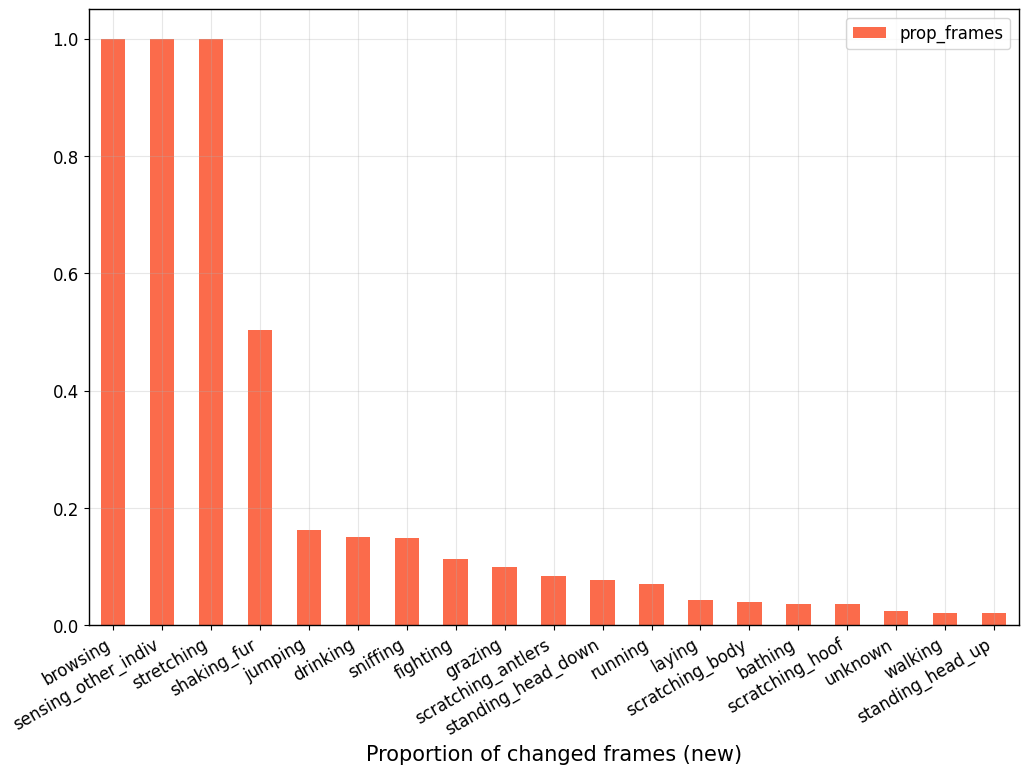

In [62]:
plot_changed_frames_frequency("attributes.action", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.action", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")

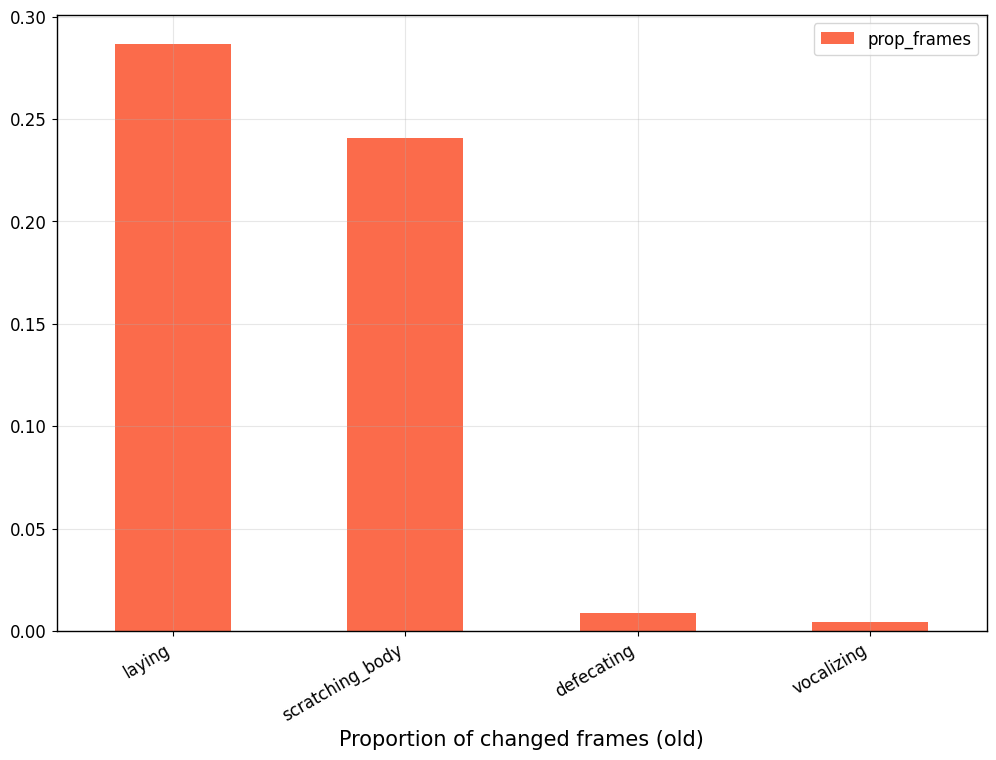

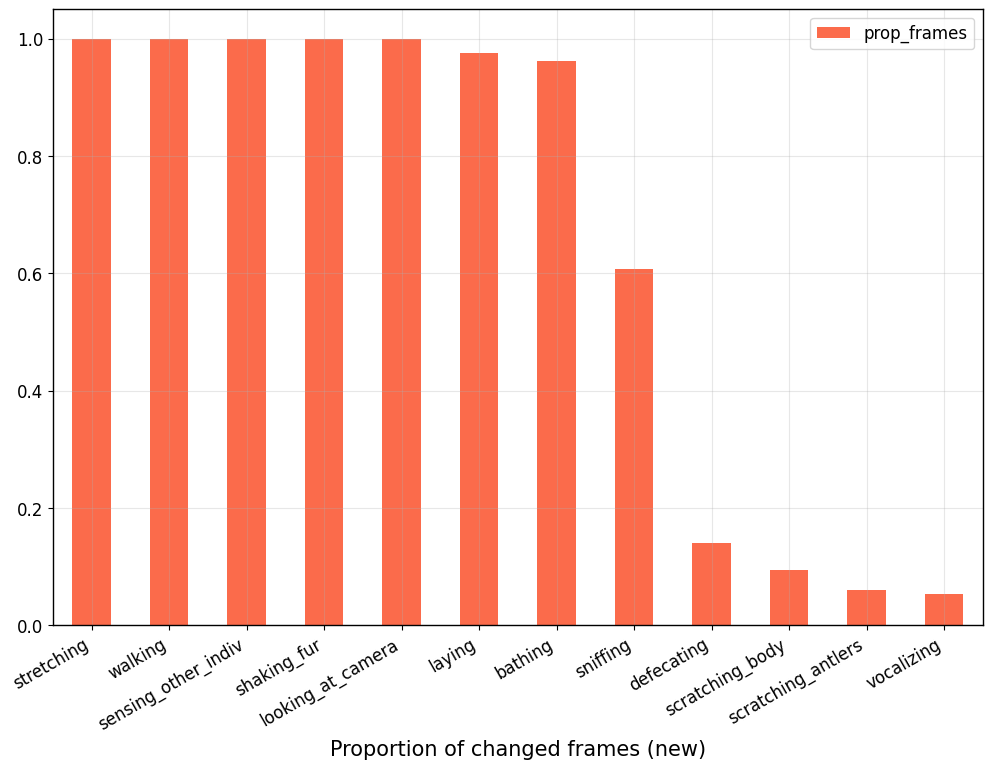

In [63]:
plot_changed_frames_frequency("attributes.action2", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.action2", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")

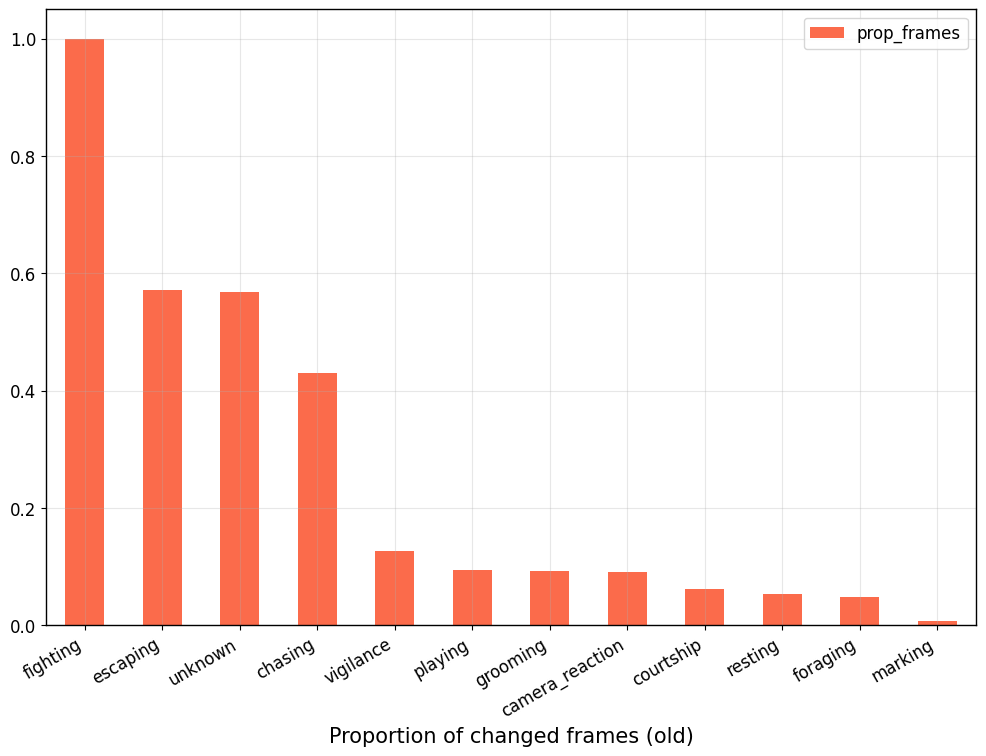

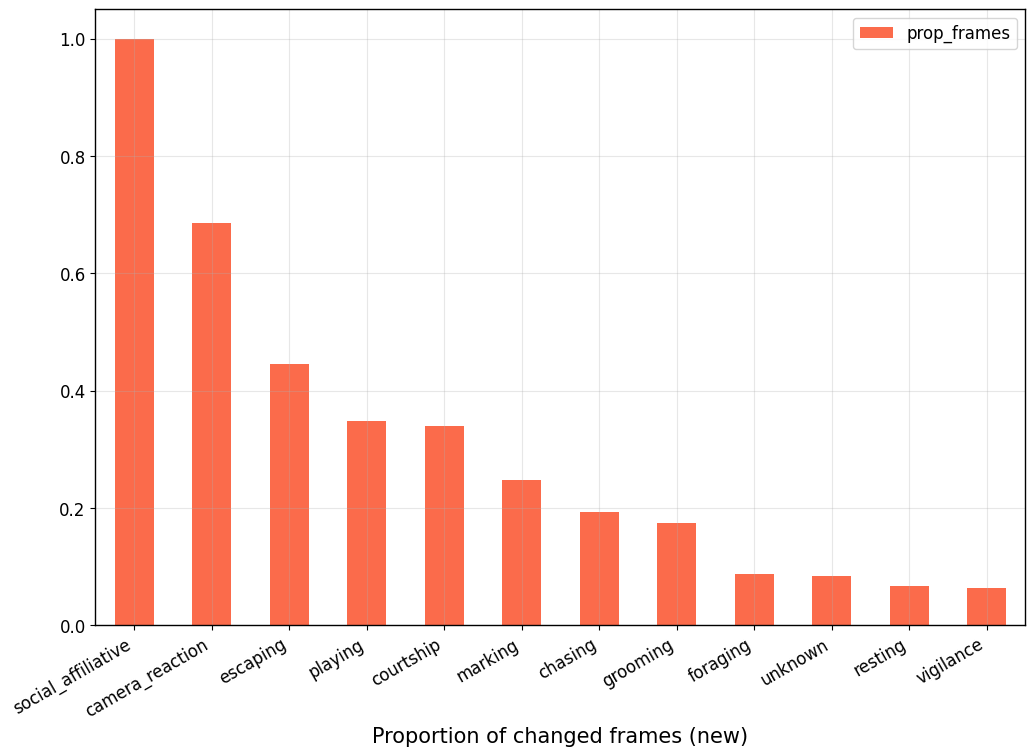

In [64]:
plot_changed_frames_frequency("attributes.activity", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.activity", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")

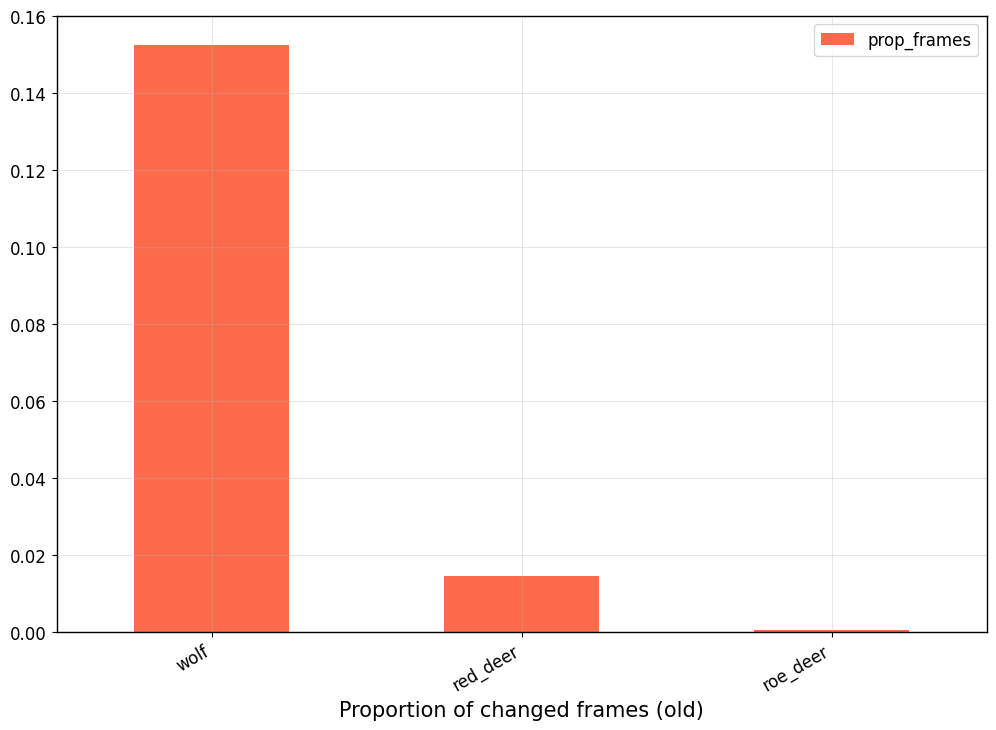

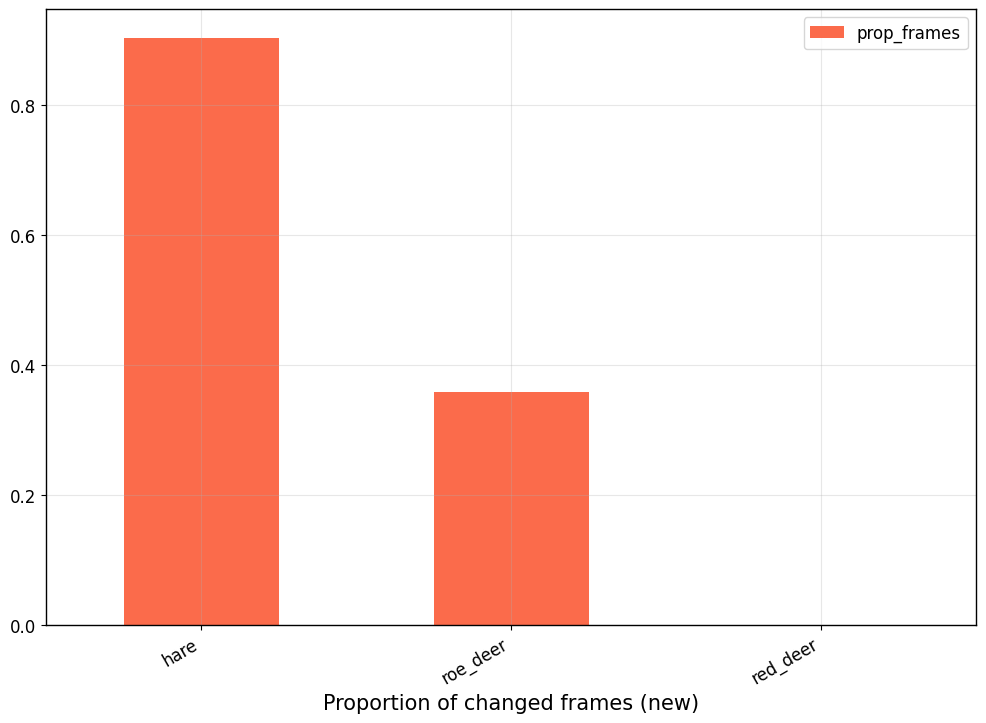

In [65]:
plot_changed_frames_frequency("attributes.species", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.species", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")

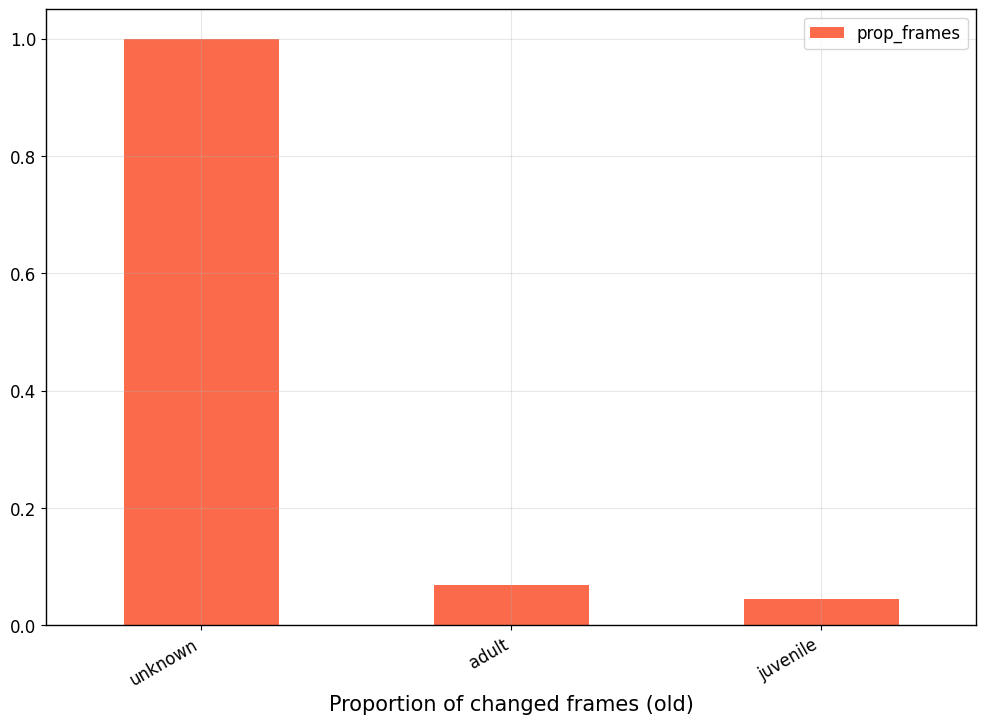

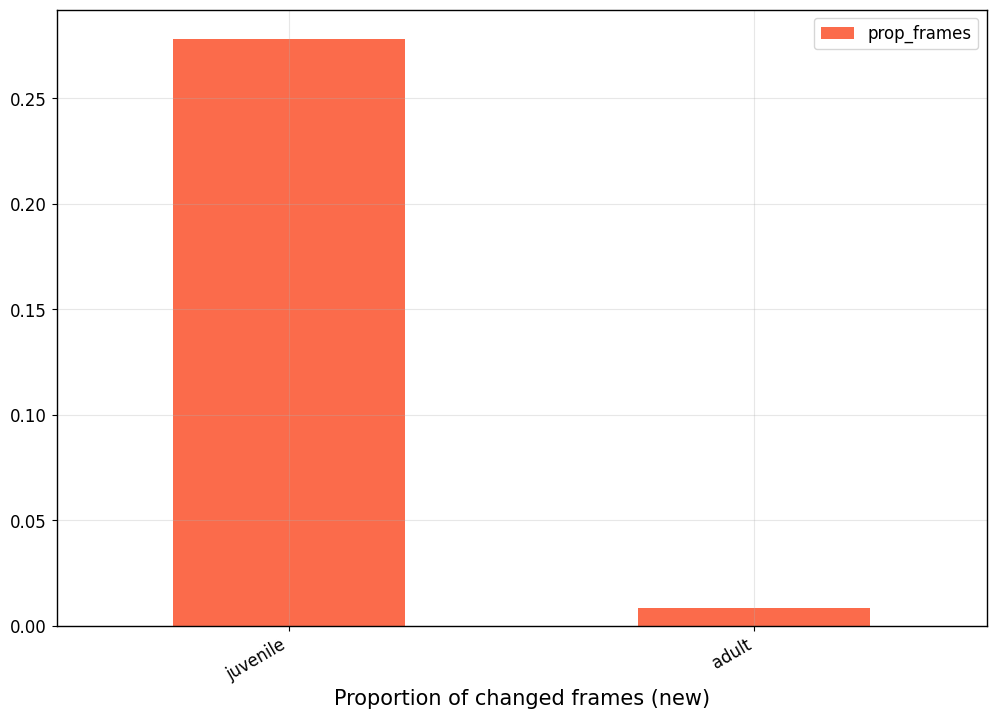

In [80]:
plot_changed_frames_frequency("attributes.deer_age", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.deer_age", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")

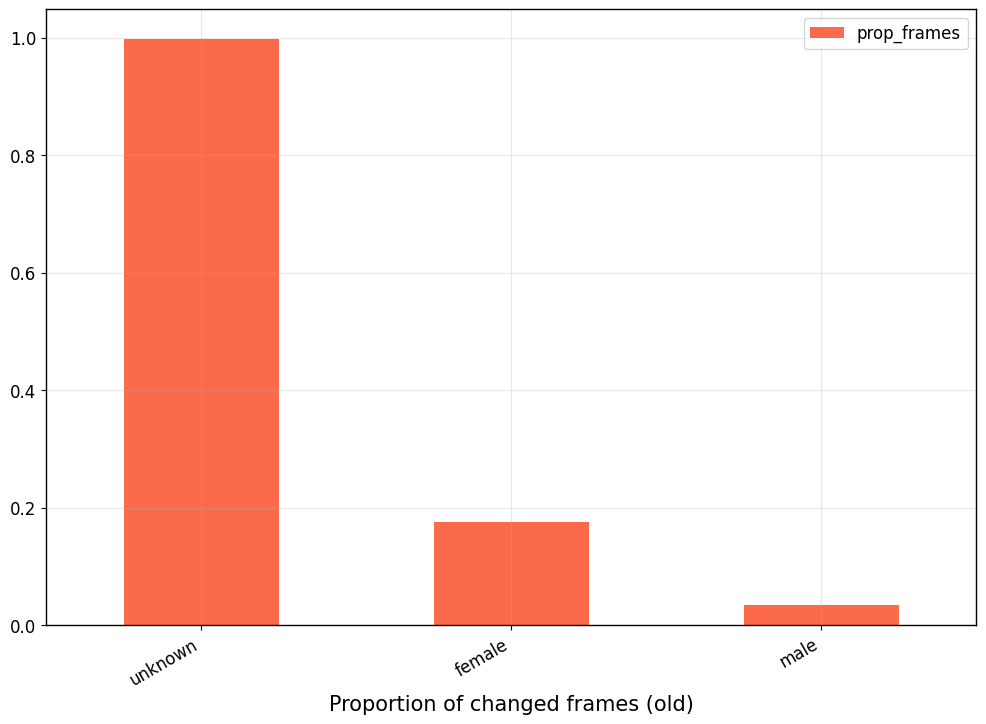

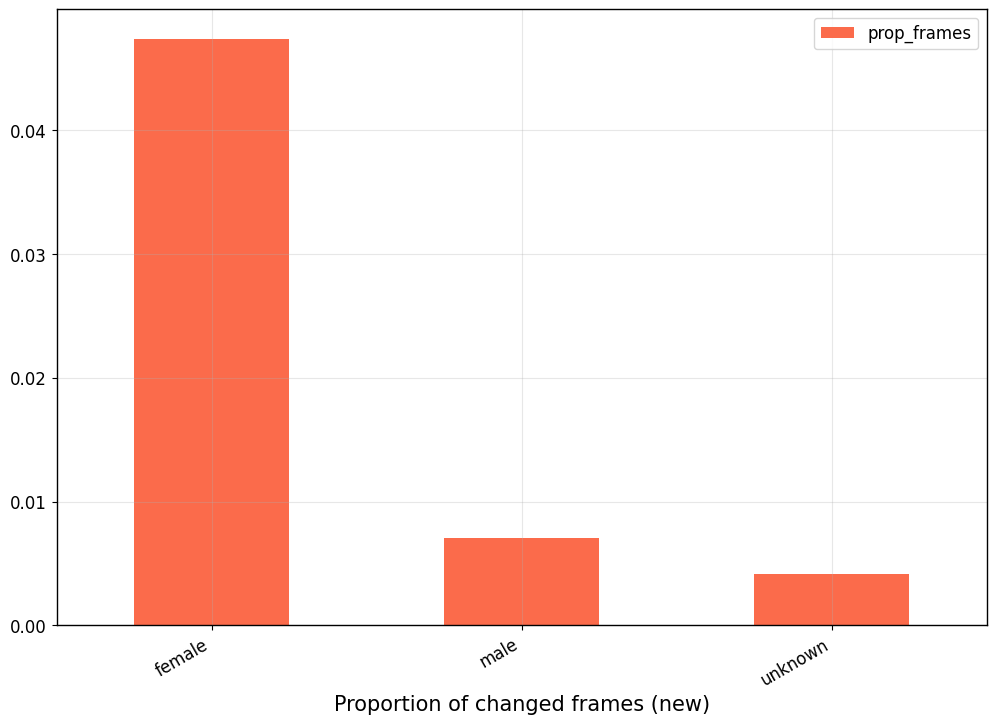

In [ ]:
plot_changed_frames_frequency("attributes.deer_adult_sex", annotated_tracklets_df_2023, diff_df, "Proportion of changed frames (old)")
plot_changed_frames_frequency("attributes.deer_adult_sex", annotated_tracklets_df_2023_updated, diff_df, "Proportion of changed frames (new)")